# 3교시 — Chunking 고도화

RAG에서 "청킹(chunking)"은 긴 문서를 임베딩/검색이 가능한 작은 조각으로 나누는 작업입니다. 어떻게 나누느냐에 따라 검색 품질이 크게 달라집니다.

이번 시간에는 같은 문서를 3가지 방식으로 나눠보면서 차이를 눈으로 확인합니다.

1. **고정 크기 분할** — 글자 수만 세서 기계적으로 자름
2. **재귀적 분할** — 문단/문장 구분자를 우선 존중하며 자름 (`01_Basic_RAG/project/ingest.py`에서 이미 쓰고 있는 방식)
3. **문서 기반 분할** — 이 문서만의 구조(제목, 표 번호 등)를 인식해서 자름

실습에는 저장소 루트 `data/`의 키오스크 이용실태 조사 PDF를 사용합니다. 이 PDF는 여러 세션 노트북이 공유하는 자료입니다. 표가 많아서, 청킹 방식에 따라 표가 중간에 잘리는지 여부를 비교하기 좋습니다.

In [1]:
import os

from langchain_community.document_loaders import PyPDFLoader

PDF_PATH = os.path.join("..", "data", "키오스크(무인정보단말기) 이용실태 조사.pdf")

# PyPDFLoader는 PDF 한 페이지를 Document 객체 하나로 만들어 리스트로 반환합니다.
pages = PyPDFLoader(PDF_PATH).load()
print(f"총 페이지 수: {len(pages)}")
print(f"1페이지 글자 수: {len(pages[0].page_content)}")

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_67129/306748603.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


총 페이지 수: 59
1페이지 글자 수: 79


## 사전 필터링

문서가 수백~수천 개라면 사람이 일일이 열어볼 수 없으니, 실무에서는 **문서 내용을 몰라도 통계·패턴만으로 판단 가능한 규칙**부터 자동으로 걸러냅니다.

1. **목차/색인 페이지** — 점선 리더(`· · · ·`)가 유난히 많이 나오면 목차로 판단
2. **각주/미주 번호** — 한글 바로 뒤에 붙는 `숫자)` 패턴(`정의하는3)`)은 각주 참조번호로 판단
3. **머리말/꼬리말** — 특정 문자열을 미리 알 필요 없이, 여러 페이지 시작 부분을 통계로 비교해서 "반복되는 부분"을 찾아냄

In [2]:
import re

def is_toc_page(text: str) -> bool:
    """점선 리더(· · · ·)가 5번 이상 나오면 목차/색인 페이지로 판단합니다."""
    return len(re.findall(r"(?:· ?){4,}", text)) >= 5


toc_page_idx = [i for i, p in enumerate(pages) if is_toc_page(p.page_content)]
print(f"목차로 판단된 페이지 인덱스: {toc_page_idx}")

목차로 판단된 페이지 인덱스: [1, 2, 3]


In [3]:
FOOTNOTE_REF = re.compile(r"(?<=[가-힣])\d{1,2}\)")


def remove_footnote_refs(text: str) -> str:
    """한글 바로 뒤에 붙는 '숫자)' 형태(각주 참조번호)를 지웁니다."""
    return FOOTNOTE_REF.sub("", text)


# 입출력 예시
example = "지능정보제품3)이며, 이는 관련 법령4)에 따른 것이다."
print(remove_footnote_refs(example))

지능정보제품이며, 이는 관련 법령에 따른 것이다.


In [4]:
from collections import Counter


def find_header_footer_pattern(pages_content: list[str]) -> re.Pattern:
    """페이지 시작 부분에서 쪽번호(숫자) 앞/뒤에 반복되는 문구를 통계로 찾아 정규식을 만듭니다."""
    heads = []
    for text in pages_content:
        m = re.match(r"(\D+)(\d+)([^\n]*)", text[:80])
        if m:
            heads.append(m.groups())

    before, before_n = Counter(h[0] for h in heads).most_common(1)[0]
    after, after_n = Counter(h[2] for h in heads).most_common(1)[0]
    print(f"반복 확인: 앞부분 {before_n}/{len(pages_content)}페이지, 뒷부분 {after_n}/{len(pages_content)}페이지에서 동일")
    return re.compile(re.escape(before) + r"\d+" + re.escape(after))


header_footer_pattern = find_header_footer_pattern([p.page_content for p in pages])
print(header_footer_pattern.pattern)

반복 확인: 앞부분 55/59페이지, 뒷부분 55/59페이지에서 동일
키오스크\(무인정보단말기\)이용\ 실태조사\
\d+\ 시장조사국\ 시장감시팀


총 55페이지에서 앞/뒷 부분에 반복되는 부분이 있었고 이를 머리말/꼬리말로 취급하여 필터링을 수행할 수 있었습니다.

In [5]:
def clean_page(text: str) -> str:
    text = header_footer_pattern.sub("", text)
    text = remove_footnote_refs(text)
    return text


clean_pages = [clean_page(p.page_content) for i, p in enumerate(pages) if i not in toc_page_idx]
print(f"전체 {len(pages)}페이지 중 목차 {len(toc_page_idx)}페이지를 제외하고, 헤더/꼬리말/각주까지 정리한 {len(clean_pages)}페이지가 남았습니다.")

전체 59페이지 중 목차 3페이지를 제외하고, 헤더/꼬리말/각주까지 정리한 56페이지가 남았습니다.


## 시연용 발췌 준비

이미 위에서 `clean_pages`로 사전 필터링을 마쳤으니, 여기서는 표가 있는 부분만 찾아서 그 주변 6페이지를 발췌합니다. [표2-1-1] 키오스크의 종류, [표2-1-2] 국내 키오스크 보급 현황 등이 포함된 구간입니다.

In [6]:
# clean_pages 안에서 [표2-1-1]이 등장하는 페이지를 찾아, 그 앞 1페이지부터 6페이지를 발췌합니다.
target_idx = next(i for i, t in enumerate(clean_pages) if "[표2-1-1]" in t)
sample_text = "".join(clean_pages[target_idx - 1 : target_idx + 5])

print(f"발췌 글자 수: {len(sample_text)}")
print(sample_text[:300])

발췌 글자 수: 5280

Ⅱ일반 현황1. 키오스크(무인정보단말기)의 정의 및 시장동향□(정의)이용자의 조작에 따라 서류 발급,정보 제공,상품 주문·결제 등의사항을 처리하기 위하여 설치하는지능정보제품ㅇ 대개 터치스크린 방식을 적용하며,관공서,은행,쇼핑몰,영화관 등 사람들이 많이 오가는 개방된 장소에서 주로 운영되고 있음. ※키오스크(Kiosk)란용어는‘거리의가판대’라는뜻의터키및페르시아에서유래한말로,현재는각종업무의무인자동화를위하여공공시설혹은거리에설치된소형구조물을일컬음.4)ㅇ 대표적 예시로는 무인민원발급기,무인발권기,무인주유기,셀프체크인,무인발매기,무인사용자 


## ① 고정 크기 분할 (Fixed-size Splitting)

가장 단순한 방식입니다. 문장이든 표든 신경 쓰지 않고 **글자 수(chunk_size)만 세서** 그 지점에서 무조건 자릅니다.

LangChain의 `CharacterTextSplitter`에 `separator=""`를 주면, 구분자를 무시하고 순수하게 글자 수 기준으로 잘라줍니다.

In [7]:
from langchain_text_splitters import CharacterTextSplitter

fixed_splitter = CharacterTextSplitter(separator="", chunk_size=300, chunk_overlap=0)
fixed_chunks = fixed_splitter.split_text(sample_text)
print(f"고정 크기 분할 청크 개수: {len(fixed_chunks)}")


def chunks_covering(chunks: list[str], start_marker: str, end_marker: str) -> list[int]:
    """start_marker~end_marker 구간(표 전체 등)이 몇 번째 청크(들)에 걸쳐 있는지 인덱스를 찾습니다."""
    joined = "".join(chunks)
    start = joined.find(start_marker)
    end = joined.find(end_marker, start)
    if end == -1:
        end = len(joined)
    pos, covering = 0, []
    for i, c in enumerate(chunks):
        if pos < end and pos + len(c) > start:
            covering.append(i)
        pos += len(c)
    return covering


# [표2-1-1] 표 전체(다음 항목인 "□(시장규모)" 직전까지)가 몇 개 청크에 걸쳐 잘렸는지 확인
idxs = chunks_covering(fixed_chunks, "[표2-1-1]", "□(시장규모)")
print(f"[표2-1-1] 표 전체가 걸쳐 있는 청크 번호: {idxs}\n")
for i in idxs:
    preview = fixed_chunks[i][:150] + ("..." if len(fixed_chunks[i]) > 150 else "")
    print(f"--- 청크 {i} ({len(fixed_chunks[i])}자) ---")
    print(preview)
    print()

고정 크기 분할 청크 개수: 18
[표2-1-1] 표 전체가 걸쳐 있는 청크 번호: [1, 2, 3, 4, 5]

--- 청크 1 (300자) ---
인증기,무인결제기,무인주문기,무인주차정산기등이 있음.5) ※금융자동화기기(은행ATM)도키오스크로분류할수있으나,이는별도의접근성표준이존재하여본조사에서는다루지않음.[그림2-1-1] 키오스크 예시 사진무인발권기무인주문기무인주차정산기
3) 「지능정보화 기본법 시행령」 제34조제...

--- 청크 2 (300자) ---
1] 키오스크의 종류
무인정보단말기
무인민원발급기o 무인민원발급기(행정, 법원, 교육 등)o 기타 국가기관 등에서 설치·운영하는 무인민원발급기무인증명발매기o 무인학사증명발급기(대학교)금융자동화기기o CD/ATM기o 공과금 수납 무인자동화기기o 환전 무인자동화기기기o A...

--- 청크 3 (300자) ---
철도, 경전철 등o 고속·시외버스 무인발매기o 국내·국제선 여객선 무인발매기o 기타 대중교통을 이용할 때 사용자 조작에 따라 승차권 등을 발권하는 무인정보단말기무인주유기o 셀프주유소 무인주유기o 전기충전소 무인충전기셀프체크인o 국내·국제선 항공/여객선 셀프체크인o 무인...

--- 청크 4 (300자) ---
자가 조작하는 무인정보단말기무인주문기o 음식(요식업, 커피, 피자, 패스트푸드, 구내식당 등) 무인주문기o 터치스크린 기반의 스마트자판기o 기타 사용자 조작에 따라 요식업 등에서 주문·결제하는 무인정보단말기무인사용자 인증기o 무인매장(편의점, 스터디카페 등) 출입 사용...

--- 청크 5 (300자) ---
인점 등에서 구매물품에 대한 무인결제기무인주차정산기o 무인주차정산기, 무인주차계산기무인도서대여반납기o 무인도서대여반납기(도서관 등)종합정보시스템o 종합안내키오스크(정부·공공청사, 박물관·미술관 등)o 관광안내키오스크(중앙정부·지자체, 공공기관 등)o 기타 사용자 조작에...



## ② 재귀적 분할 (Recursive Splitting)

`RecursiveCharacterTextSplitter`는 `["\n\n", "\n", " ", ""]` 순서로 텍스트를 쪼갭니다. 문단(`\n\n`) 단위로 먼저 나눠보고, 그래도 chunk_size를 넘으면 문장/단어 단위로 더 잘게 쪼갭니다.

`01_Basic_RAG/project/ingest.py`가 실제로 이 방식(chunk_size=1500)을 쓰고 있습니다. 여기서는 비교를 위해 같은 chunk_size=300으로 맞춰서 봅니다.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# chunk_overlap은 0으로 맞춰서, "구분자를 존중하는지" 차이만 순수하게 비교합니다. (overlap은 뒤에서 따로 다룹니다)
recursive_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=0)
recursive_chunks = recursive_splitter.split_text(sample_text)
print(f"재귀적 분할 청크 개수: {len(recursive_chunks)}")

idxs = chunks_covering(recursive_chunks, "[표2-1-1]", "□(시장규모)")
print(f"[표2-1-1] 표 전체가 걸쳐 있는 청크 번호: {idxs}\n")
for i in idxs:
    preview = recursive_chunks[i][:150] + ("..." if len(recursive_chunks[i]) > 150 else "")
    print(f"--- 청크 {i} ({len(recursive_chunks[i])}자) ---")
    print(preview)
    print()

재귀적 분할 청크 개수: 22
[표2-1-1] 표 전체가 걸쳐 있는 청크 번호: [2, 3, 4, 5, 6]

--- 청크 2 (193자) ---
3) 「지능정보화 기본법 시행령」 제34조제1항제3호 황석원·김원석, 「패스트푸드점의 무인주문결제 키오스크 사용자 경험 연구」, 디지털콘텐츠학회논문지, 제20권 제8호, 2019, 1492쪽 우선구매지능정보제품의 종류(「장애인·고령자 등의 정보 접근 및 이용 편의 증진...

--- 청크 3 (298자) ---
무인민원발급기o 무인민원발급기(행정, 법원, 교육 등)o 기타 국가기관 등에서 설치·운영하는 무인민원발급기무인증명발매기o 무인학사증명발급기(대학교)금융자동화기기o CD/ATM기o 공과금 수납 무인자동화기기o 환전 무인자동화기기기o AI 카드 발매 무인자동화기기o 기타 ...

--- 청크 4 (288자) ---
무인발매기o 국내·국제선 여객선 무인발매기o 기타 대중교통을 이용할 때 사용자 조작에 따라 승차권 등을 발권하는 무인정보단말기무인주유기o 셀프주유소 무인주유기o 전기충전소 무인충전기셀프체크인o 국내·국제선 항공/여객선 셀프체크인o 무인숙박업소 셀프체크인o 기타 사용자 ...

--- 청크 5 (298자) ---
무인정보단말기무인주문기o 음식(요식업, 커피, 피자, 패스트푸드, 구내식당 등) 무인주문기o 터치스크린 기반의 스마트자판기o 기타 사용자 조작에 따라 요식업 등에서 주문·결제하는 무인정보단말기무인사용자 인증기o 무인매장(편의점, 스터디카페 등) 출입 사용자 인증 무인정...

--- 청크 6 (271자) ---
구매물품에 대한 무인결제기무인주차정산기o 무인주차정산기, 무인주차계산기무인도서대여반납기o 무인도서대여반납기(도서관 등)종합정보시스템o 종합안내키오스크(정부·공공청사, 박물관·미술관 등)o 관광안내키오스크(중앙정부·지자체, 공공기관 등)o 기타 사용자 조작에 따라 정보 ...



## ③ 문서 기반 분할 (Structure-aware Splitting)

재귀적 분할도 결국 "이 문서가 어떤 구조인지"는 모릅니다. 이 보고서는 실제로 아래와 같은 자기만의 구조 표시를 갖고 있습니다.

- `Ⅰ`, `Ⅱ`, `Ⅲ` … : 대제목
- `1.`, `2.` … : 소제목
- `□` : 문단(항목) 시작
- `[표...]`, `[그림...]` : 표/그림 블록 시작

이 마커들이 나오는 지점을 기준으로 나누면, chunk_size라는 숫자 대신 **문서 자체의 구조**를 경계로 쓸 수 있습니다. 즉 표나 문단이 항상 통째로 한 청크에 들어갑니다.

먼저 작은 예시로 함수가 어떻게 동작하는지 확인해봅니다.

In [9]:
# 대제목(Ⅰ,Ⅱ..), 소제목(1. 2. ..), 문단(□), 표/그림([표.. [그림..) 시작 지점을 경계로 잡는 정규식
SECTION_MARKER = re.compile(r"(?=[Ⅰ-Ⅷ][가-힣])|(?=\d+\.\s?[가-힣])|(?=□)|(?=\[표|\[그림)")


def split_by_structure(text: str) -> list[str]:
    """텍스트를 문서 구조 마커(대제목/소제목/문단/표·그림) 경계로 나눕니다."""
    positions = [m.start() for m in SECTION_MARKER.finditer(text)]
    if not positions or positions[0] != 0:
        positions = [0] + positions
    positions.append(len(text))
    chunks = [text[positions[i] : positions[i + 1]].strip() for i in range(len(positions) - 1)]
    return [c for c in chunks if c]


# 입출력 예시로 동작 확인
example = "Ⅱ일반 현황1. 정의□(정의)키오스크는 무인단말기다. [표1] 종류표...□(현황)최근 늘고 있다."
for c in split_by_structure(example):
    print(repr(c))

'Ⅱ일반 현황'
'1. 정의'
'□(정의)키오스크는 무인단말기다.'
'[표1] 종류표...'
'□(현황)최근 늘고 있다.'


In [10]:
structure_chunks = split_by_structure(sample_text)
print(f"문서 기반 분할 청크 개수: {len(structure_chunks)}")

idxs = chunks_covering(structure_chunks, "[표2-1-1]", "□(시장규모)")
print(f"[표2-1-1] 표 전체가 걸쳐 있는 청크 번호: {idxs}\n")
for i in idxs:
    preview = structure_chunks[i][:150] + ("..." if len(structure_chunks[i]) > 150 else "")
    print(f"--- 청크 {i} ({len(structure_chunks[i])}자) ---")
    print(preview)
    print()

문서 기반 분할 청크 개수: 18
[표2-1-1] 표 전체가 걸쳐 있는 청크 번호: [4]

--- 청크 4 (1184자) ---
[표2-1-1] 키오스크의 종류
무인정보단말기
무인민원발급기o 무인민원발급기(행정, 법원, 교육 등)o 기타 국가기관 등에서 설치·운영하는 무인민원발급기무인증명발매기o 무인학사증명발급기(대학교)금융자동화기기o CD/ATM기o 공과금 수납 무인자동화기기o 환전 무인자동화...



## 3가지 방식 비교

같은 발췌를 두고 세 방식이 청크를 몇 개로 나눴는지, 그리고 [표2-1-1]을 몇 조각으로 잘랐는지 한눈에 비교합니다.

In [11]:
results = {
    "고정 크기 분할": fixed_chunks,
    "재귀적 분할": recursive_chunks,
    "문서 기반 분할": structure_chunks,
}

print(f"{'방식':<12}{'청크 개수':<10}{'평균 길이':<10}{'[표2-1-1] 조각 수'}")
for name, chunks in results.items():
    avg_len = sum(len(c) for c in chunks) / len(chunks)
    table_pieces = len(chunks_covering(chunks, "[표2-1-1]", "□(시장규모)"))
    print(f"{name:<12}{len(chunks):<10}{avg_len:<10.0f}{table_pieces}")

방식          청크 개수     평균 길이     [표2-1-1] 조각 수
고정 크기 분할    18        293       5
재귀적 분할      22        239       5
문서 기반 분할    18        293       1


이렇게 보면 문서 기반 chunking이 제일 좋아 보일 수 있지만 이 방법도 단점이 있습니다.

* **청크 크기의 균일함** : 문서 기반 < 재귀적 분할 < 고정 크기 분할. 너무 짧은 문서는 쓸모가 없고 너무 긴 문서는 오히려 모델이 핵심을 파악하기 어렵게 할 수 있음. -> 문서 기반 분할을 먼저 하고 재귀적 분할을 다시 적용하는 식의 후처리 고려해 볼 수 있음.
* **재사용성** : 문서 기반 chunking은 이 문서에만 적용 가능합니다. 다양한 문서를 chunking하는 경우엔 일일이 적용하기 어렵습니다.

## ④ 표 처리하기 (pdfplumber)

지금까지 본 세 방식은 전부 `pypdf`가 뽑아준 텍스트를 어떻게 자르느냐의 문제였습니다. 그런데 [표2-1-2]처럼 **숫자가 여러 열(2019년/2021년)로 나뉜 표**는 애초에 `pypdf` 단계에서부터 셀 구분이 사라져서, 아무리 잘 잘라도 복구가 안 됩니다.

```
가. 무인행정민원3,904대4,613대   ← 3,904대가 2019년인지 2021년인지 텍스트만 봐서는 알 수 없음
```

`pdfplumber`는 PDF의 선(line)과 여백을 분석해서 표를 행/열이 살아있는 상태로 뽑아줍니다.

In [12]:
import pdfplumber

with pdfplumber.open(PDF_PATH) as pdf:
    table_page = pdf.pages[9]  # 인덱스 9 = [표2-1-2]가 있는 페이지
    tables = table_page.extract_tables()

print(f"이 페이지에서 찾은 표 개수: {len(tables)}")

kiosk_table = tables[0]  # [표2-1-2] 국내 키오스크 보급 현황
for row in kiosk_table:
    print(row)

이 페이지에서 찾은 표 개수: 3
['분야', None, '운영대수(추정)', None]
[None, None, '2019년', '2021년']
['1. 공공분야', None, '181,364대', '183,459대']
['', '가. 무인행정민원', '3,904대', '4,613대']
[None, '나. 은행', '133,390대', '127,509대']
[None, '다. 병원', '35,333대', '41,312대']
[None, '라. 교통', '8,230대', '9,382대']
[None, '마. 대학(대학교, 전문대)', '507대', '643대']
['2. 민간분야', None, '8,587대', '26,874대']
['', '가. 영화관', '1,930대', '2,281대']
[None, '나. 대형마트', '1,178대', '1,738대']
[None, '다. 요식업', '5,479대', '21,335대']
[None, '라. 생활편의', '-', '1,200대']
['합계', None, '189,951대', '210,033대']


In [13]:
def rows_to_markdown(rows: list[list[str]]) -> str:
    """pdfplumber가 뽑은 표(행 리스트)를 마크다운 표 문자열로 변환합니다. LLM에 표를 넘길 때 이 형태가 읽기 좋습니다."""
    lines = []
    for row in rows:
        cells = [(c or "").replace("\n", " ") for c in row]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


# 입출력 예시
example_rows = [["분야", "2019년", "2021년"], ["공공분야", "181,364대", "183,459대"]]
print(rows_to_markdown(example_rows))

| 분야 | 2019년 | 2021년 |
| 공공분야 | 181,364대 | 183,459대 |


In [14]:
# pypdf(텍스트만 추출)로는 같은 표가 어떻게 보이는지 다시 확인
pypdf_start = sample_text.find("[표2-1-2]")
pypdf_end = sample_text.find("2. 키오스크 관련 사회적 이슈")
pypdf_view = sample_text[pypdf_start:pypdf_end].strip()

print("--- pypdf: 셀 구분 없이 텍스트가 다 붙어 있음 ---")
print(pypdf_view[:200], "...")

print("\n--- pdfplumber: 행/열이 살아있는 마크다운 표 ---")
print(rows_to_markdown(kiosk_table))

--- pypdf: 셀 구분 없이 텍스트가 다 붙어 있음 ---
[표2-1-2] 국내 키오스크 보급 현황(추정)분야운영대수(추정)2019년2021년1.공공분야181,364대183,459대가. 무인행정민원3,904대4,613대나. 은행133,390대127,509대다. 병원35,333대41,312대라. 교통8,230대9,382대마. 대학(대학교, 전문대) 507대643대2. 민간분야8,587대26,874대가. 영화관1,93 ...

--- pdfplumber: 행/열이 살아있는 마크다운 표 ---
| 분야 |  | 운영대수(추정) |  |
|  |  | 2019년 | 2021년 |
| 1. 공공분야 |  | 181,364대 | 183,459대 |
|  | 가. 무인행정민원 | 3,904대 | 4,613대 |
|  | 나. 은행 | 133,390대 | 127,509대 |
|  | 다. 병원 | 35,333대 | 41,312대 |
|  | 라. 교통 | 8,230대 | 9,382대 |
|  | 마. 대학(대학교, 전문대) | 507대 | 643대 |
| 2. 민간분야 |  | 8,587대 | 26,874대 |
|  | 가. 영화관 | 1,930대 | 2,281대 |
|  | 나. 대형마트 | 1,178대 | 1,738대 |
|  | 다. 요식업 | 5,479대 | 21,335대 |
|  | 라. 생활편의 | - | 1,200대 |
| 합계 |  | 189,951대 | 210,033대 |


## ⑤ 이미지는 어떻게 처리할까 (소개)

이 문서에는 [그림2-1-1], [그림2-1-2] 같은 차트도 있습니다. 그런데 `pypdf`가 뽑아주는 "임베디드 이미지"(`page.images`)는 대부분 130×150px짜리 불릿 아이콘 같은 장식용 그림이고, 진짜 차트는 대부분 **벡터 그래픽**(선·막대를 좌표로 직접 그린 것)이라 이미지로 추출되지 않습니다.

방법을 두 가지만 간단히 소개합니다.

1. **임베디드 이미지 추출**: PDF 안에 진짜 사진/스캔본이 박혀 있을 때만 유효합니다 (`page.images`). 이 문서처럼 차트가 벡터로 그려져 있으면 못 잡습니다.
2. **페이지를 통째로 이미지로 렌더링**: 벡터/래스터 구분 없이 페이지를 화면 캡처하듯 그대로 이미지로 만들어서, Vision LLM(멀티모달 모델)에게 "이 차트를 설명해줘"라고 넘기는 방식입니다. `pdfplumber`의 `page.to_image()`로 간단히 확인할 수 있습니다.

또, 설명을 토대로 관련 문서를 찾은 다음 이미지 경로를 함께 전달해 VLM이 원본 이미지를 확인할 수 있도록 하는 것도 방법이 될 수 있습니다.

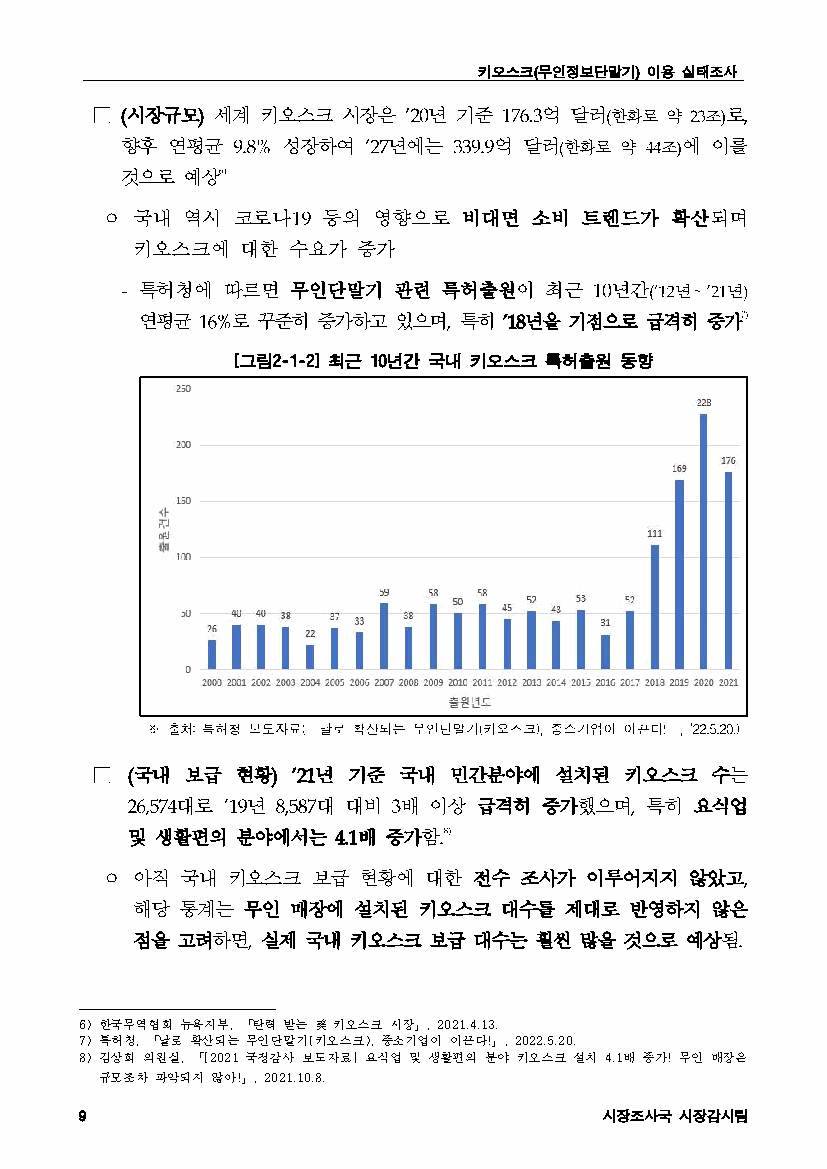

In [15]:
# [그림2-1-2]가 실제로 등장하는 페이지를 찾습니다. (목차 페이지에도 같은 텍스트가 나오므로 toc_page_idx는 제외)
target_page_idx = next(
    i for i, p in enumerate(pages) if i not in toc_page_idx and "[그림2-1-2]" in p.page_content
)

with pdfplumber.open(PDF_PATH) as pdf:
    page_image = pdf.pages[target_page_idx].to_image(resolution=100)

page_image